In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as T
from sklearn.metrics import f1_score

In [2]:
class Net(nn.Module):
    def __init__(self, in_channels=3, num_classes=10):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.linear = nn.Linear(128 * 8 * 8, num_classes)

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        return self.linear(x)

In [3]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total = 0
    correct = 0
    loss_sum = 0.0
    y_all = []
    pred_all = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            loss_sum += loss.item() * x.size(0)
            pred = logits.argmax(1)
            correct += (pred == y).sum().item()
            total += x.size(0)
            y_all.append(y.cpu().numpy())
            pred_all.append(pred.cpu().numpy())

    y_true = np.concatenate(y_all)
    y_pred = np.concatenate(pred_all)
    acc = correct / total
    f1 = f1_score(y_true, y_pred, average="macro")
    return loss_sum / total, acc, f1

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total = 0
    correct = 0
    loss_sum = 0.0
    y_all = []
    pred_all = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * x.size(0)
        pred = logits.argmax(1)
        correct += (pred == y).sum().item()
        total += x.size(0)
        y_all.append(y.detach().cpu().numpy())
        pred_all.append(pred.detach().cpu().numpy())
        
    y_true = np.concatenate(y_all)
    y_pred = np.concatenate(pred_all)
    acc = correct / total
    f1 = f1_score(y_true, y_pred, average="macro")
    return loss_sum / total, acc, f1

In [4]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dir = "./data"

batch_size = 64
epochs = 30
lr = 0.1

In [5]:
train_tfms = T.Compose([
    T.RandomHorizontalFlip(),
    T.ToTensor()
])
test_tfms = T.ToTensor()

trainset = torchvision.datasets.CIFAR10(root=data_dir, train=True, download=True, transform=train_tfms)
testset  = torchvision.datasets.CIFAR10(root=data_dir, train=False, download=True, transform=test_tfms)

val_size = int(len(trainset) * 0.05)
train_size = len(trainset) - val_size
train_subset, val_subset = random_split(
    trainset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_subset,   batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(testset,      batch_size=batch_size, shuffle=False, num_workers=2)

In [6]:
model = Net(in_channels=3, num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=0.0001)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

In [7]:
for ep in range(1, epochs + 1):
        train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        print(f"epoch {ep:02d}/{epochs} | "
              f"train: loss {train_loss:.4f} acc {train_acc*100:.2f}% f1 {train_f1:.3f} | "
              f"val:   loss {val_loss:.4f} acc {val_acc*100:.2f}% f1 {val_f1:.3f}")

_, test_acc, test_f1 = evaluate(model, test_loader, criterion, device)
print(f"TEST | acc {test_acc*100:.2f}% f1 {test_f1:.3f}")

epoch 01/30 | train: loss 1.6447 acc 41.45% f1 0.410 | val:   loss 1.4709 acc 48.04% f1 0.459
epoch 02/30 | train: loss 1.2112 acc 57.40% f1 0.572 | val:   loss 1.5747 acc 46.72% f1 0.433
epoch 03/30 | train: loss 1.0537 acc 63.48% f1 0.634 | val:   loss 1.1328 acc 59.20% f1 0.594
epoch 04/30 | train: loss 0.9594 acc 66.93% f1 0.668 | val:   loss 1.0411 acc 64.40% f1 0.637
epoch 05/30 | train: loss 0.8927 acc 69.23% f1 0.691 | val:   loss 1.0223 acc 64.56% f1 0.643
epoch 06/30 | train: loss 0.8386 acc 71.22% f1 0.712 | val:   loss 1.0417 acc 64.72% f1 0.638
epoch 07/30 | train: loss 0.7917 acc 72.89% f1 0.728 | val:   loss 1.0142 acc 65.28% f1 0.648
epoch 08/30 | train: loss 0.7512 acc 74.15% f1 0.741 | val:   loss 0.9265 acc 68.24% f1 0.677
epoch 09/30 | train: loss 0.7157 acc 75.58% f1 0.755 | val:   loss 0.8905 acc 69.32% f1 0.697
epoch 10/30 | train: loss 0.6778 acc 76.66% f1 0.766 | val:   loss 0.8864 acc 68.68% f1 0.690
epoch 11/30 | train: loss 0.6509 acc 77.83% f1 0.778 | val: 

In [8]:
torch.save({"model": model.state_dict()}, "./model.ckpt")

In [10]:
import math
import matplotlib.pyplot as plt

In [11]:
model_loaded = Net(in_channels=3, num_classes=10).to(device)
checkpoint = torch.load("./model.ckpt", map_location=device)
model.load_state_dict(checkpoint["model"])
model.eval()

Net(
  (conv): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (linear): Linear(in_features=8192, out_features=10, bias=True)
)

In [14]:
def get_classes(obj):
    seen = set()
    while obj is not None and id(obj) not in seen:
        seen.add(id(obj))
        if hasattr(obj, "classes") and obj.classes:
            return list(obj.classes)
        obj = getattr(obj, "dataset", None)
    return None

def collect_misclassified(model, loader, max_examples=16, device=None):
    model.eval()

    mis = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(x)
            pred = logits.argmax(dim=1)

            wrong_mask = pred.ne(y)
            if wrong_mask.any():
                wrong_idx = wrong_mask.nonzero(as_tuple=False).squeeze(1)
                for idx in wrong_idx:
                    mis.append({
                        "image": x[idx].cpu(),
                        "true": y[idx].item(),
                        "pred": pred[idx].item(),
                    })
                    if len(mis) >= max_examples:
                        return mis
    return mis

def show_misclassified(mis, classes=None, cols=4, figsize=(12, 9)):
    rows = math.ceil(len(mis) / cols)
    plt.figure(figsize=figsize)
    for i, ex in enumerate(mis, 1):
        plt.subplot(rows, cols, i)
        img = ex["image"]
        if isinstance(img, torch.Tensor):
            img = img.detach().cpu()
            if img.dim() == 3 and img.shape[0] in (1, 3, 4):
                img = img.squeeze(0) if img.shape[0] == 1 else img.permute(1, 2, 0)
            img = img.numpy()
        plt.imshow(img)
        plt.axis("off")

        t = ex["true"]
        p = ex["pred"]
        t_name = classes[t] if classes and t < len(classes) else str(t)
        p_name = classes[p] if classes and p < len(classes) else str(p)

        plt.title(f"pred: {p_name}\ntrue: {t_name}", fontsize=9)

    plt.tight_layout()
    plt.show()

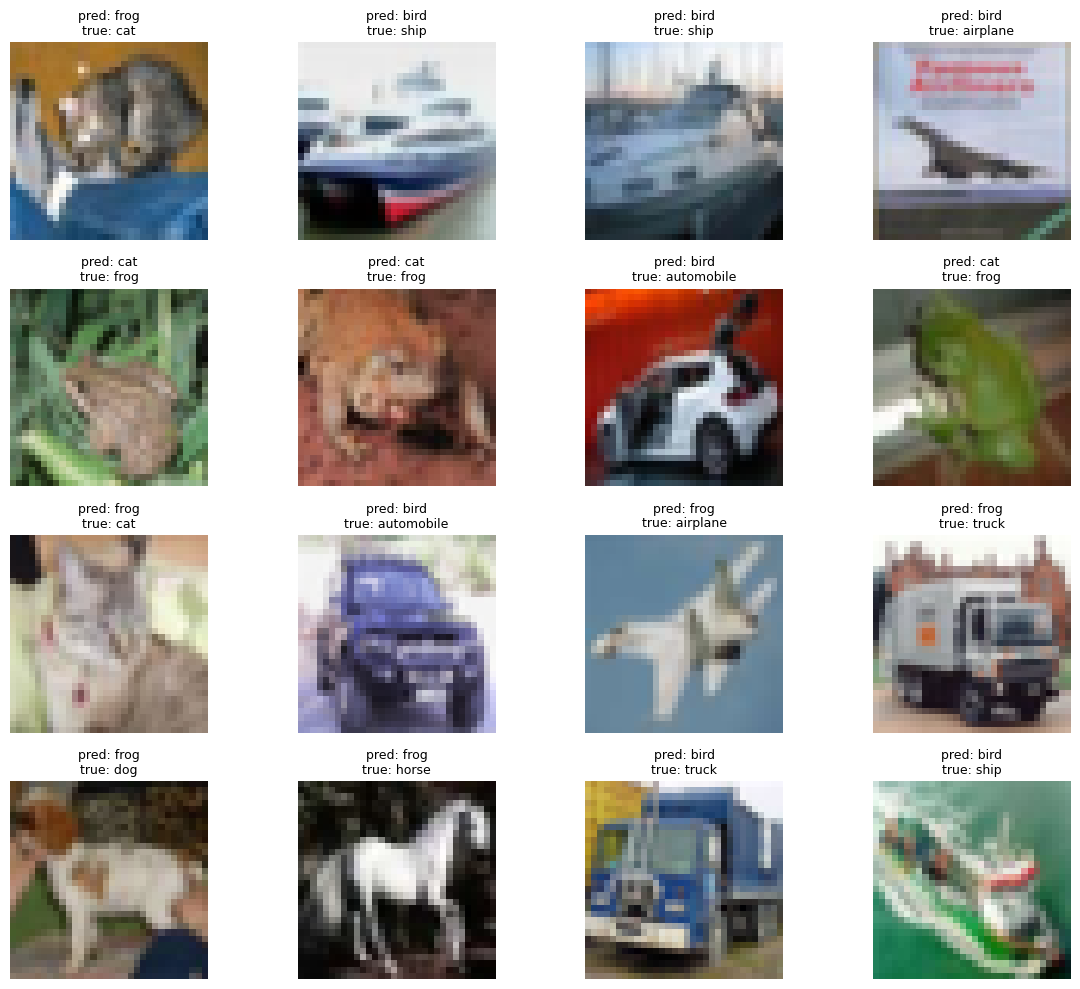

In [15]:
classes = get_classes(test_loader.dataset)
mis = collect_misclassified(model_loaded, test_loader, max_examples=16, device=device)
show_misclassified(mis, classes=classes, cols=4, figsize=(12, 10))

Архитектура модели

1 слой - Свертка ядром 3x3 + ReLU + MaxPool 2x2 | 3x32x32 -> 64x32x32 -> 64x16x16

2 слой - Свертка ядром 3x3 + ReLU + MaxPool 2x2 | 64x16x16 -> 128x16x16 -> 128x8x8

3 слой - Flatten | 128x8x8 -> 8192

4 слой - Полносвязный 8192 + 10 нейронов | 8192 -> 10


Для решения данной задачи классификации с точностью более 70% достаточно 2 стандартных сверточных слоев с базовой функцией активации ReLU, чтобы не тратить вычислительные ресурсы. Для уменьшения размерности был использован пулинг 2x2 с шагом 2, который хоть и замедляет работу модели за счет большого числа параметров, но уменьшает количество эпох, необходимое для обучения. (при использовании MaxPool 4x4 аналогичные показатели точности были получены только после 50 эпохи). Размеры полносвязного слоя обусловлены только числом признаков на выходе Flatten и количеством классов.


На тестовом датасете модель показала точность 76.8% и macro F1 0.768. Несмотря на то, что на валидации модель достигла точности 60% на 4 эпохе, было решено проверить насколько высокие показатели будут при обучении на 30 эпохах(большиее количество не использовалось из-за скорости обучения).